# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [1]:
import polars as pl
import uproot
from fastfeedback import *


caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]
Enu_e_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG = "rec/mc/mc.nu/mc.nu.pdg"
data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

df: pl.DataFrame = pl.from_pandas(ak.to_dataframe(data, how="outer"))
df.columns = ["Enu_e_had", "Enu_e_calo", "Enu_mu_had", "Enu_mu_range", "PDG"]

reco_pfp_tree = uproot.open("example-cafs-root/reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df: pl.DataFrame = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

electron_mask = pl.col("PDG").abs() == 12
muon_mask = pl.col("PDG").abs() == 14
tau_mask = pl.col("PDG").abs() == 16

electron_inelasticity = 1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))
muon_inelasticity = 1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))

nu_mask = pl.col("PDG") > 0
nubar_mask = pl.col("PDG") < 0

data: pl.DataFrame = (
    pl.concat([df, reco_pfp_df], how="horizontal")
    .filter(pl.col("reco_ok") == True)
    .drop("reco_ok")
    .with_columns(
        pl.when(electron_mask)
        .then(electron_inelasticity)
        .when(muon_mask)
        .then(muon_inelasticity)
        .otherwise(None)
        .alias("inelasticity")
    )
    .drop_nulls()
)

data

Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity
f32,f32,f32,f32,i32,i32,i32,i32,f32,i32,i32,f32
12.376396,28.432413,28.015844,28.529816,-12,10,5,4,11.48799,4,1,0.564708
0.09995,0.208079,0.09995,0.322256,-12,2,1,0,0.11094,1,0,0.519653
0.306345,1.156426,0.306345,1.20171,-14,4,3,0,0.06457,2,1,0.745076
0.088844,0.502835,0.088844,0.5937,14,3,2,0,0.00242,1,1,0.850355
0.0,0.021875,0.0,0.1223,-12,2,1,0,0.010483,0,1,1.0
…,…,…,…,…,…,…,…,…,…,…,…
-8.1044e-17,0.156685,0.0,0.256748,14,2,1,0,0.0,1,0,1.0
0.002552,0.169946,0.002552,0.260973,14,2,1,0,0.005397,1,0,0.990219
0.014027,0.12414,0.014027,0.207403,14,3,1,1,0.012165,1,0,0.932367


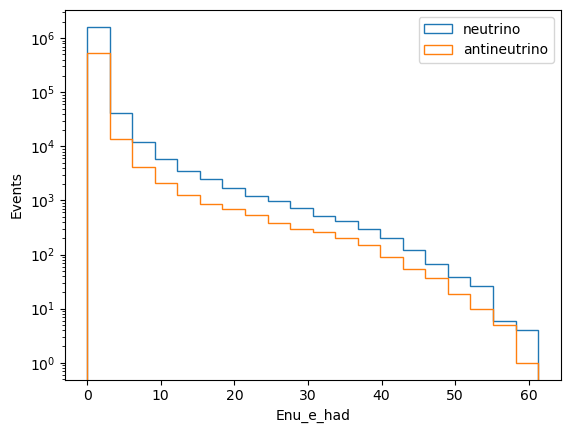

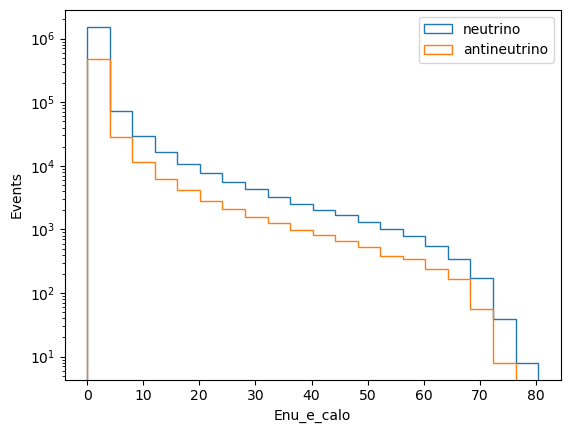

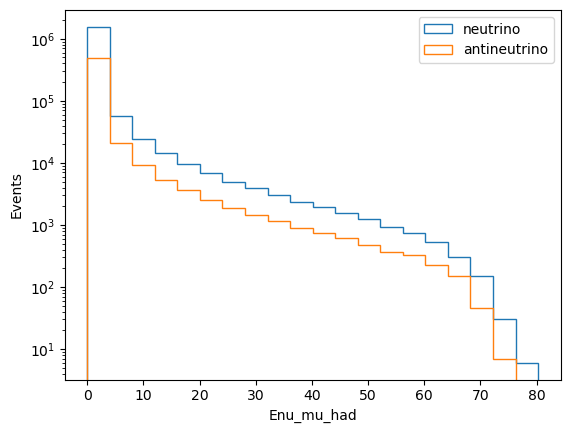

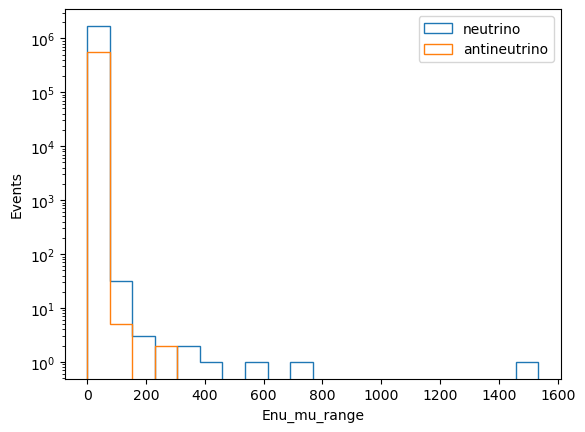

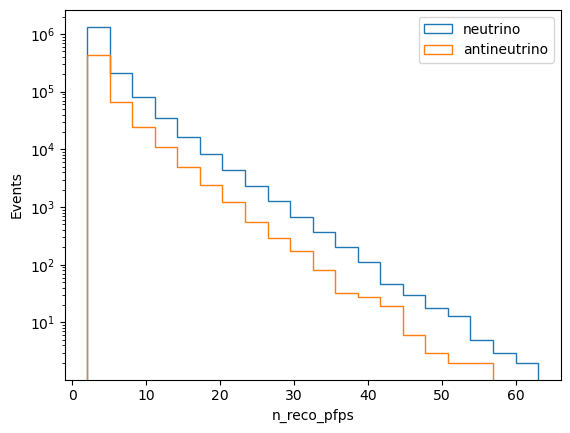

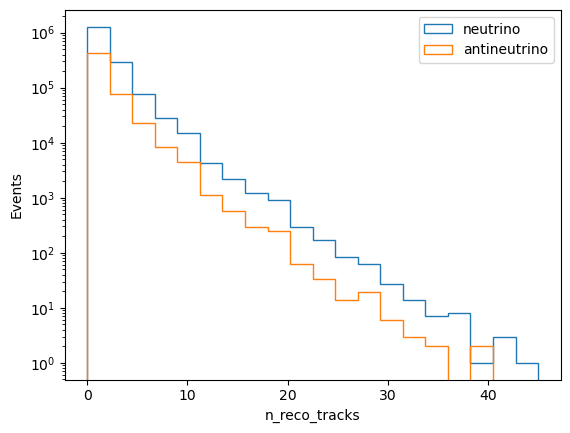

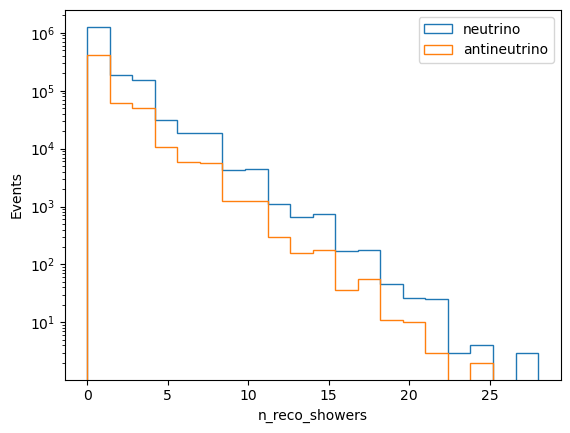

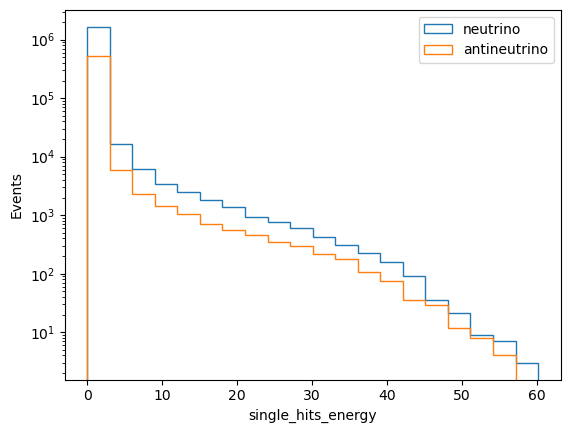

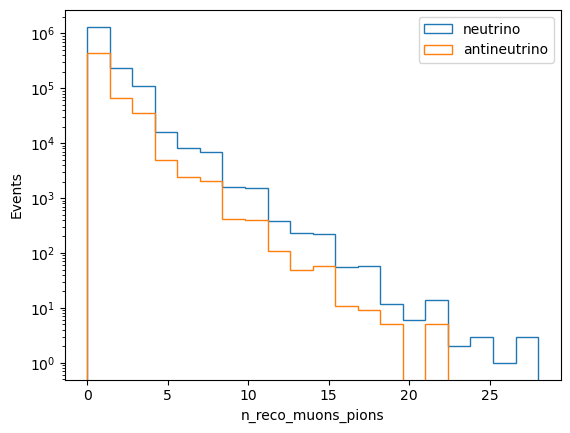

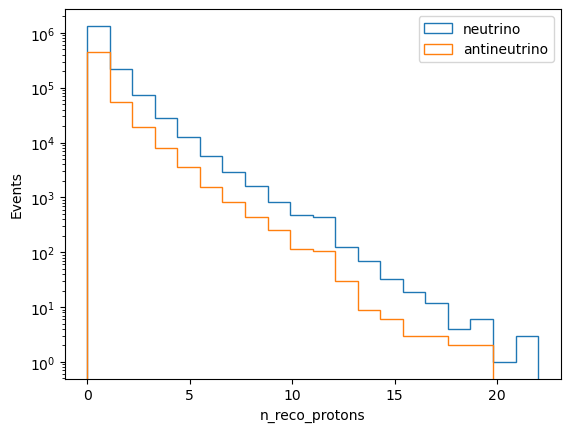

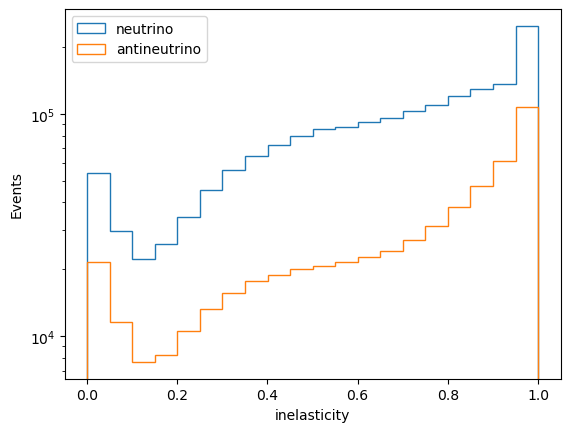

In [2]:
import matplotlib.pyplot as plt

for col in data.columns:
    if col == "PDG":
        continue

    _, bins, _ = plt.hist(
        data.filter(nu_mask)[col], label="neutrino", histtype="step", bins=20
    )
    plt.hist(
        data.filter(nubar_mask)[col], label="antineutrino", histtype="step", bins=bins
    )
    plt.legend()
    plt.yscale("log")
    plt.xlabel(col)
    plt.ylabel("Events")
    plt.show()

In [3]:
from sklearn.model_selection import train_test_split

# get your input data into an array which is N_events x N_variables
X_data = data.to_numpy()

# create an array of truth labels (one per event) - 0 for neutrino, 1 for anti-neutrino
y_data = (data["PDG"] < 0).to_numpy().astype(int)
y_data_uniques = np.unique(y_data)
print(y_data_uniques)

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data)

[0 1]


Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier().fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [5]:
# this will be a value between 0 and 1 for each event, indicating "probability" that the event is anti-neutrino

# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

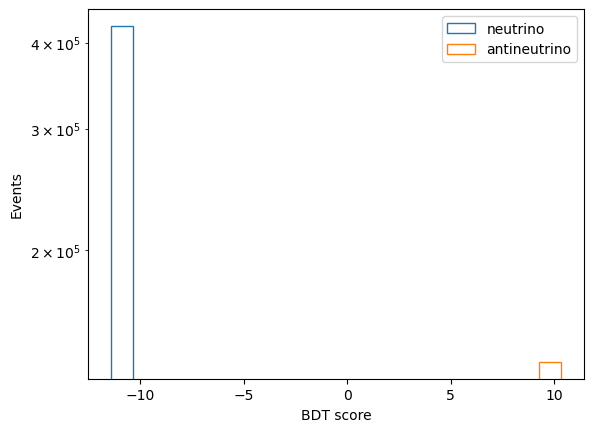

423164.0


In [6]:
nu_index = 0
nubar_index = 1

n, bins, _ = plt.hist(
    scores_test[y_test == nu_index],
    label="neutrino",
    histtype="step",
    bins=20,
    range=(scores_test.min(), scores_test.max()),
)
plt.hist(
    scores_test[y_test == nubar_index], label="antineutrino", histtype="step", bins=bins
)
plt.legend()
plt.yscale("log")
plt.xlabel("BDT score")
plt.ylabel("Events")
plt.show()

print(np.sum(n))

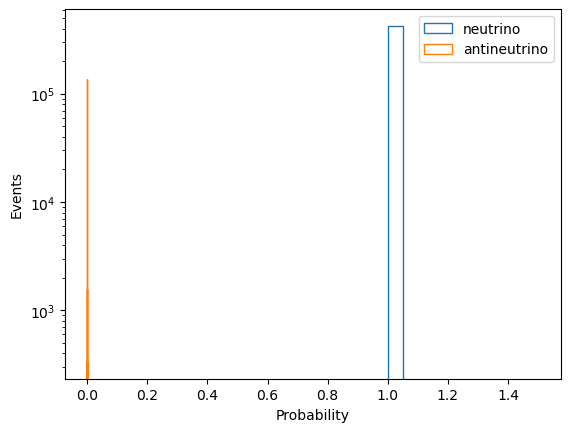

/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


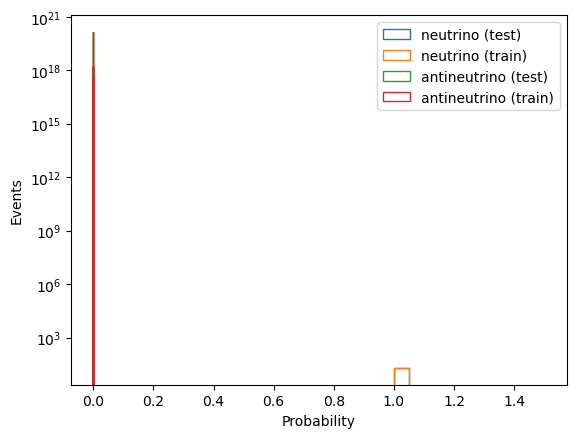

In [7]:
prob_test_nu = 1 / (1 + np.exp(scores_test[y_test == nu_index]))
prob_test_nubar = 1 / (1 + np.exp(scores_test[y_test == nubar_index]))
prob_train_nu = 1 / (1 + np.exp(scores_train[y_train == nu_index]))
prob_train_nubar = 1 / (1 + np.exp(scores_train[y_train == nubar_index]))

_, bins, _ = plt.hist(prob_test_nu, label="neutrino", histtype="step", bins=20)
plt.hist(prob_test_nubar, label="antineutrino", histtype="step", bins=20)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

_, bins, _ = plt.hist(
    prob_test_nu, label="neutrino (test)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_train_nu, label="neutrino (train)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_test_nubar, label="antineutrino (test)", histtype="step", bins=20, density=True
)
plt.hist(
    prob_train_nubar,
    label="antineutrino (train)",
    histtype="step",
    bins=20,
    density=True,
)
plt.legend()
plt.yscale("log")
plt.xlabel("Probability")
plt.ylabel("Events")
plt.show()

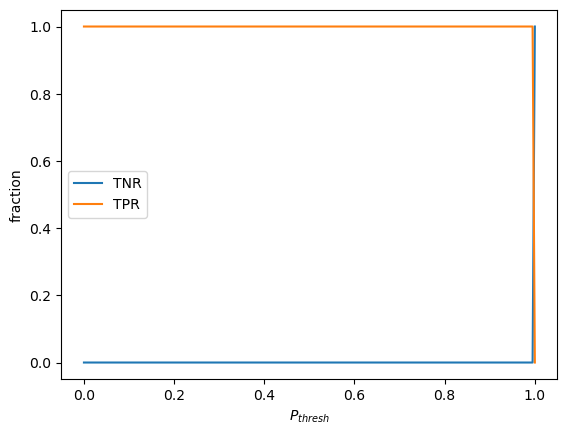

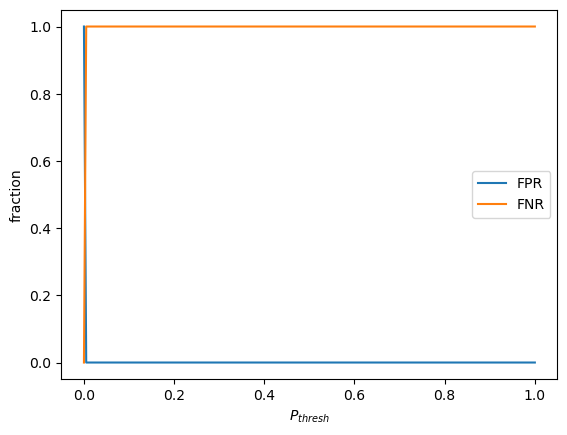

In [8]:
score_thresh = np.linspace(0, 1, 200)

tpr = [(prob_test_nu > score).sum() / len(prob_test_nu) for score in score_thresh]
fpr = [(prob_test_nubar > score).sum() / len(prob_test_nubar) for score in score_thresh]
tnr = [(prob_test_nu < score).sum() / len(prob_test_nu) for score in score_thresh]
fnr = [(prob_test_nubar < score).sum() / len(prob_test_nubar) for score in score_thresh]

plt.plot(score_thresh, tnr, label="TNR")
plt.plot(score_thresh, tpr, label="TPR")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("$P_{thresh}$")
plt.show()

plt.plot(score_thresh, fpr, label="FPR")
plt.plot(score_thresh, fnr, label="FNR")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("$P_{thresh}$")
plt.show()

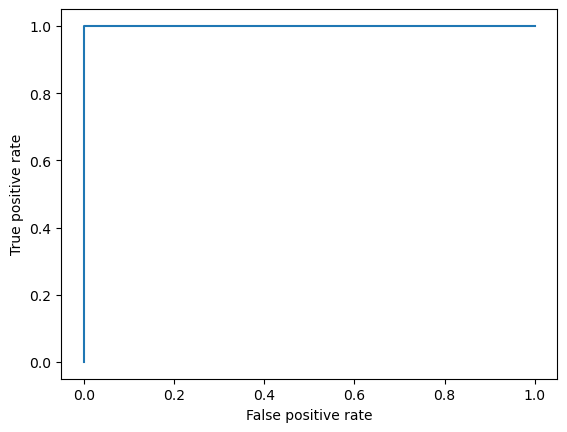

AUC =  1.0


In [9]:
from scipy.integrate import trapezoid

# ROC
plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.show()

# AUC
auc = trapezoid(x=fpr[::-1], y=tpr[::-1])
print("AUC = ", auc)

In [10]:
thresh = 0.85
tp_cm = (prob_test_nu > thresh).sum()
tn_cm = (prob_test_nubar < thresh).sum()
fn_cm = (prob_test_nu < thresh).sum()
fp_cm = (prob_test_nubar > thresh).sum()

print(tp_cm, fn_cm)
print(fp_cm, tn_cm)

423164 0
0 137492


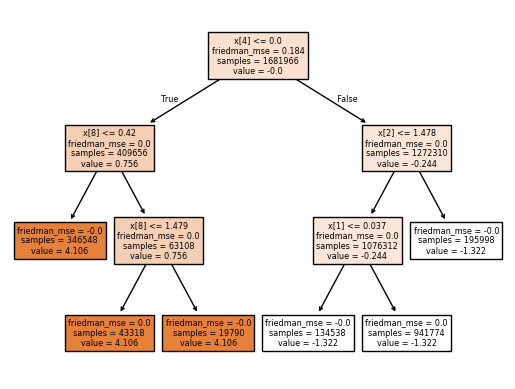

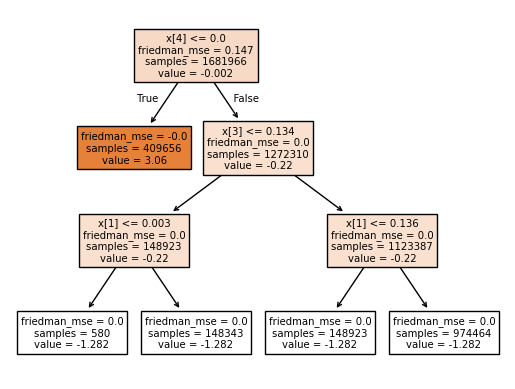

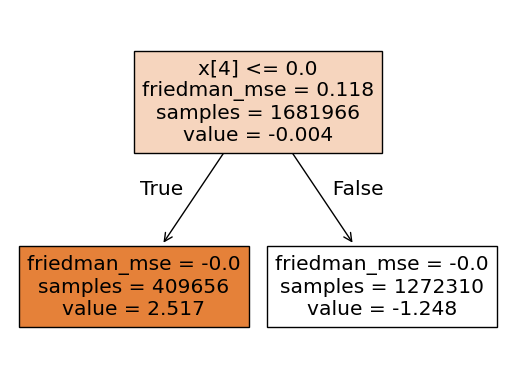

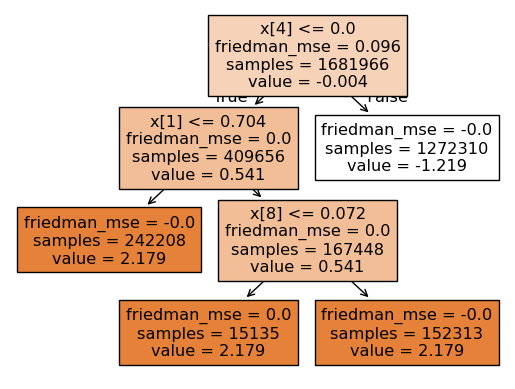

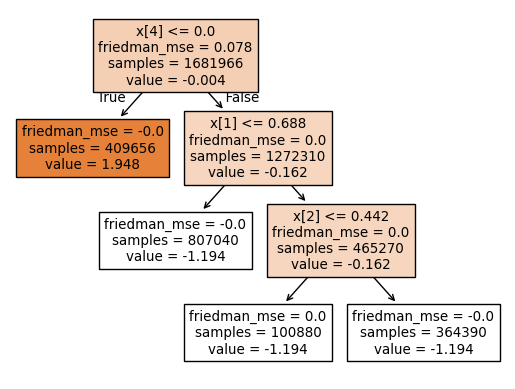

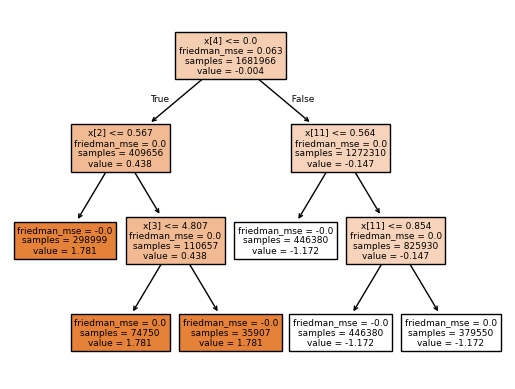

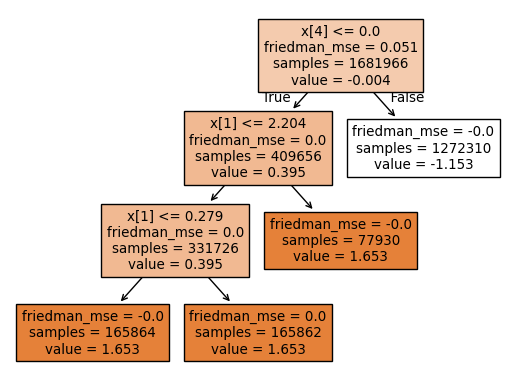

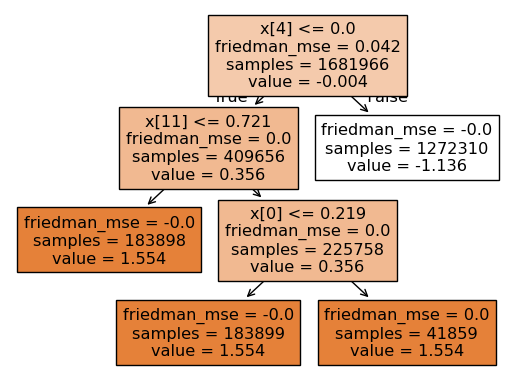

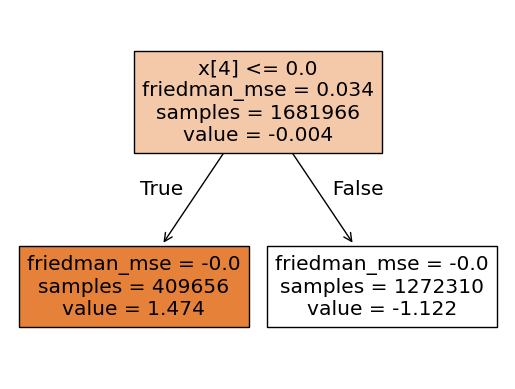

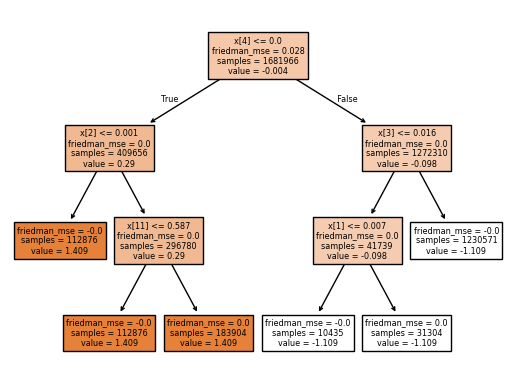

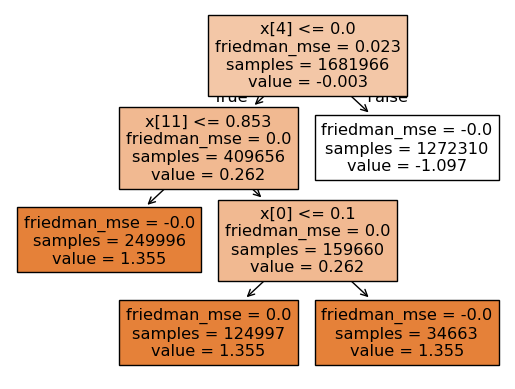

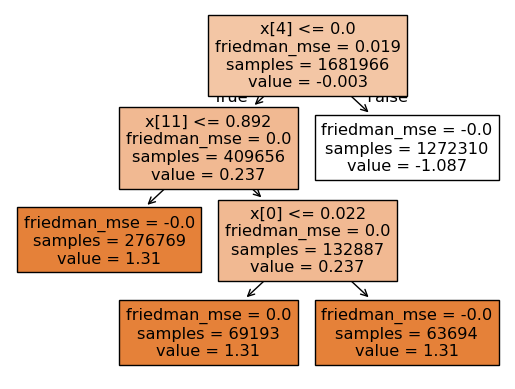

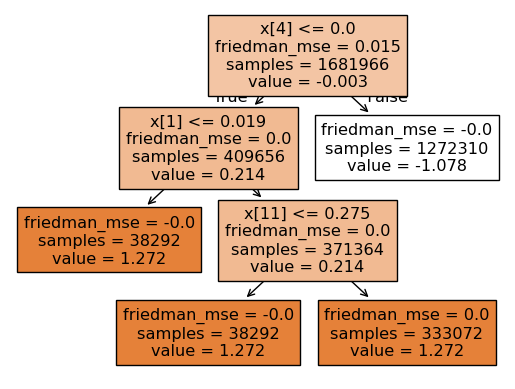

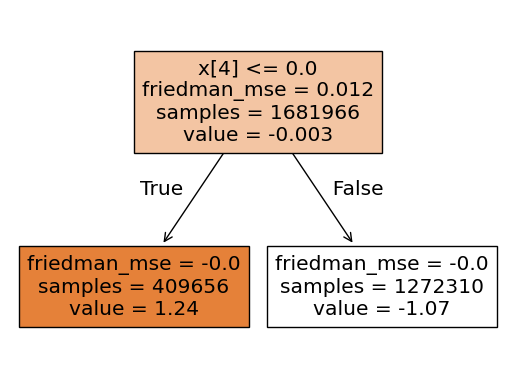

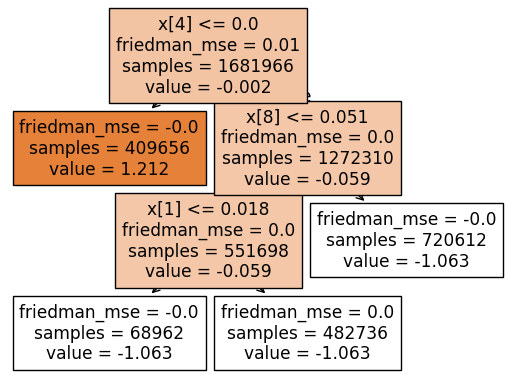

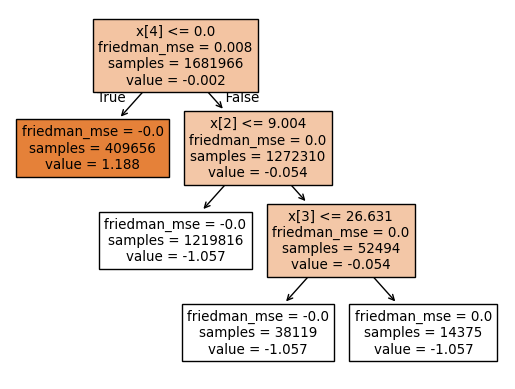

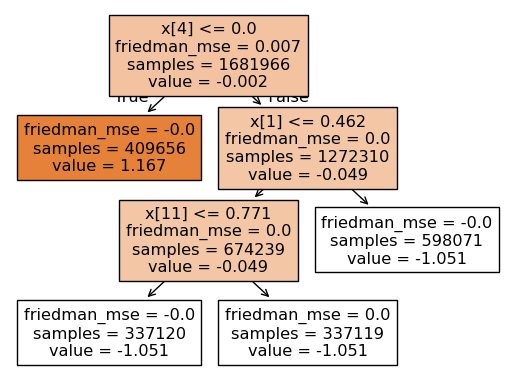

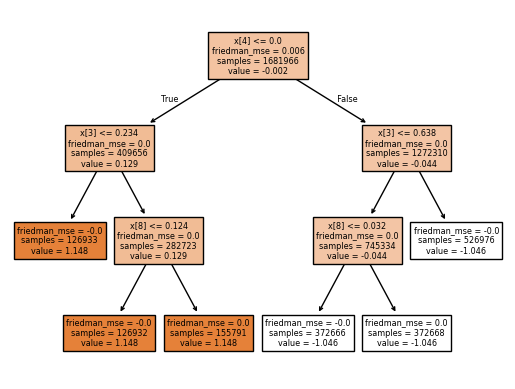

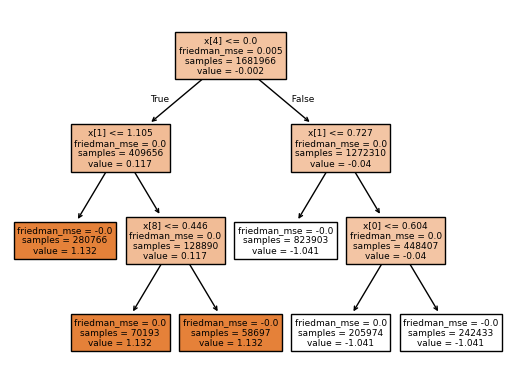

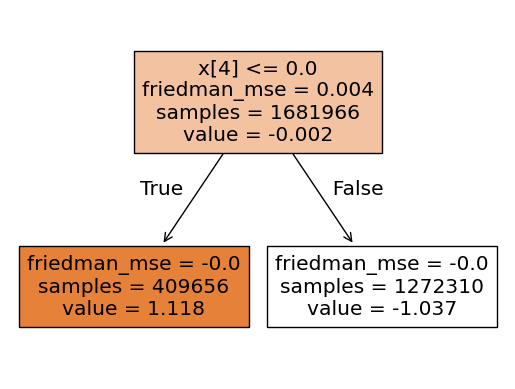

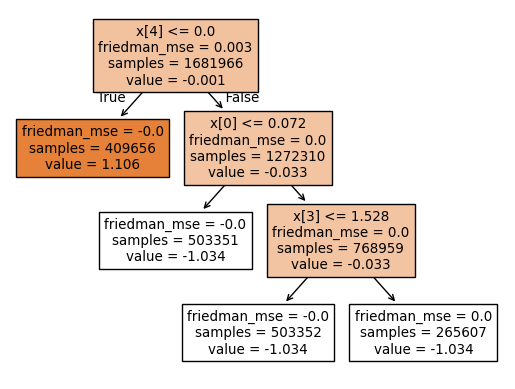

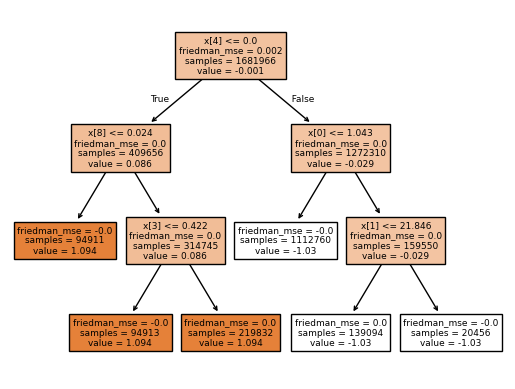

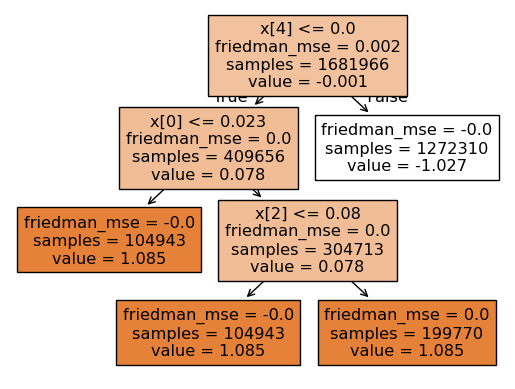

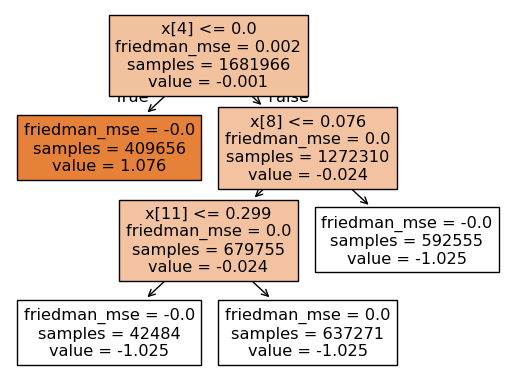

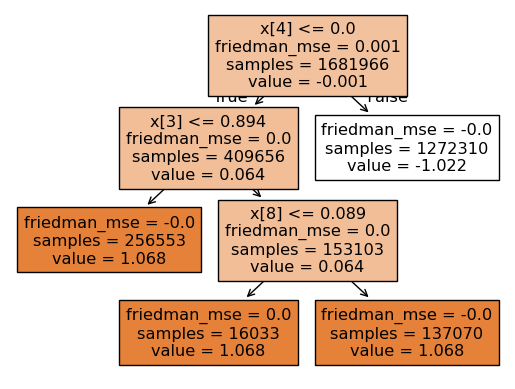

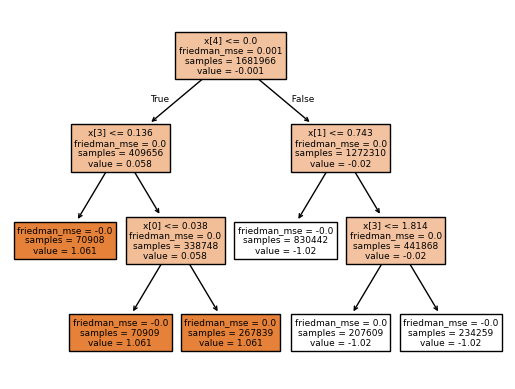

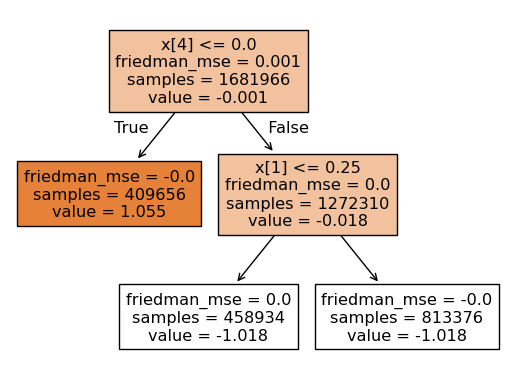

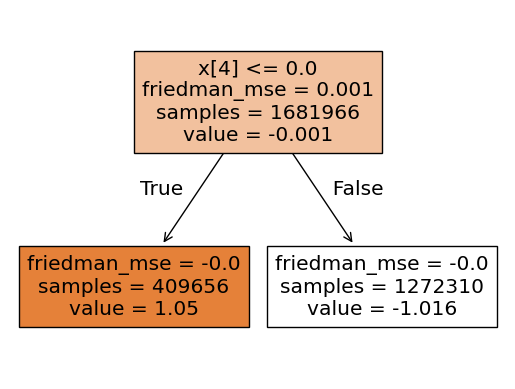

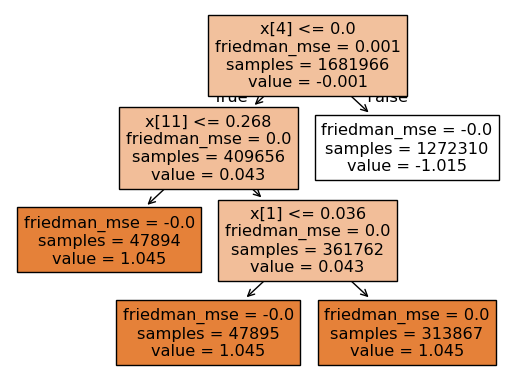

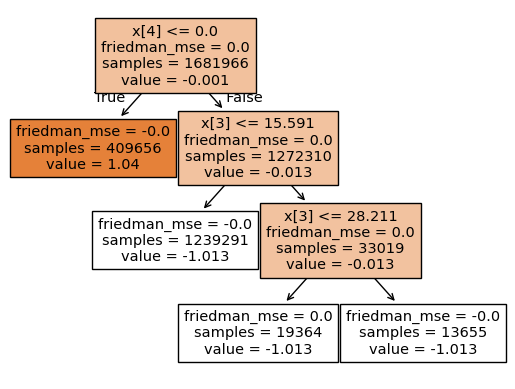

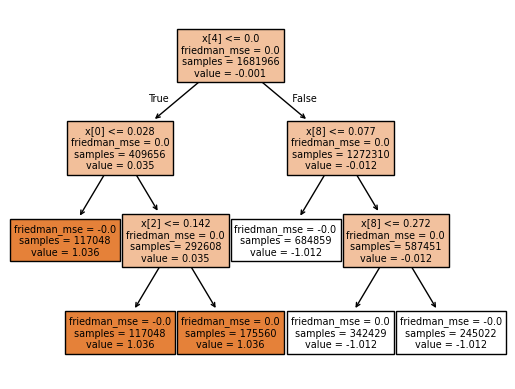

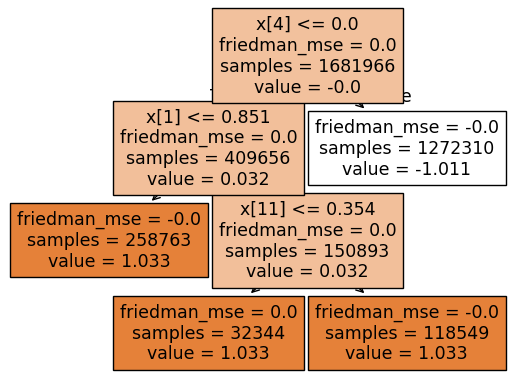

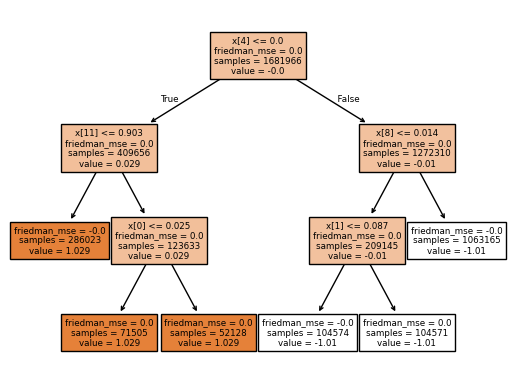

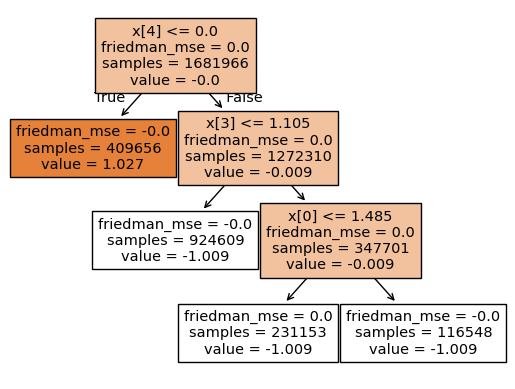

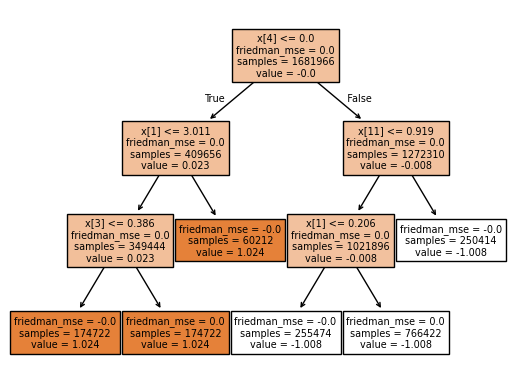

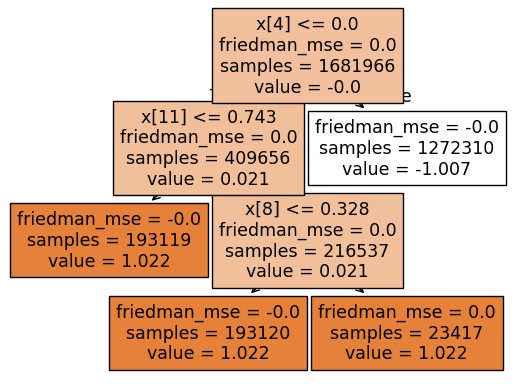

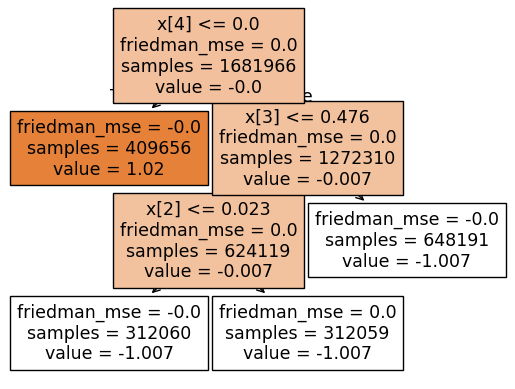

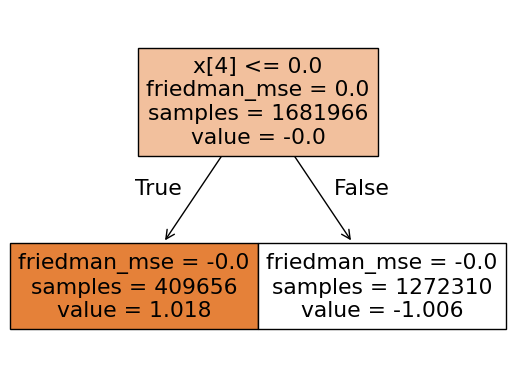

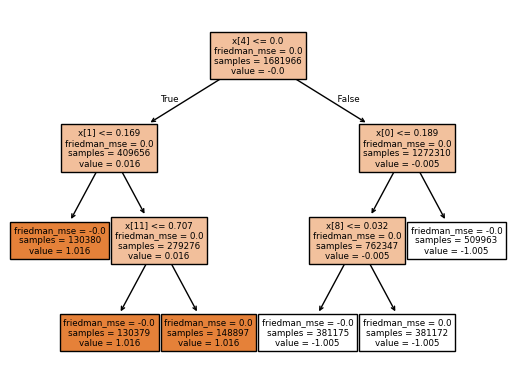

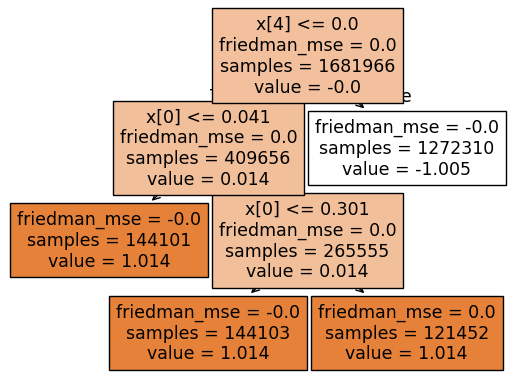

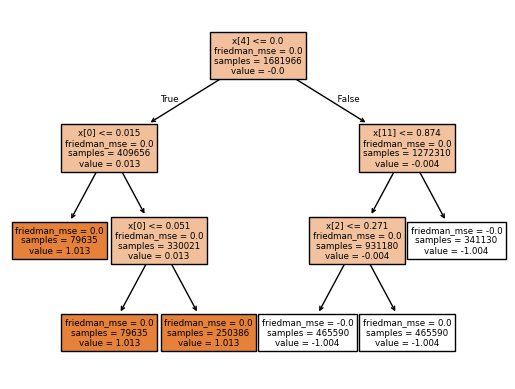

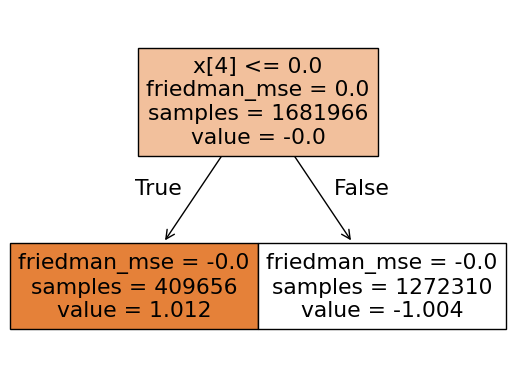

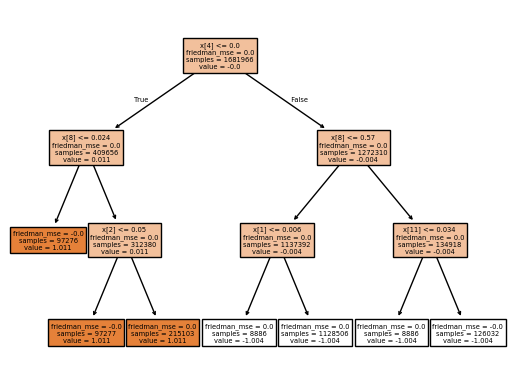

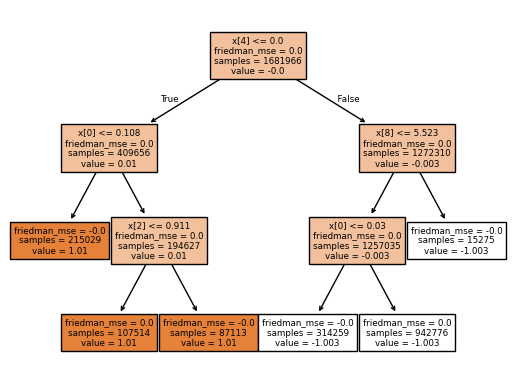

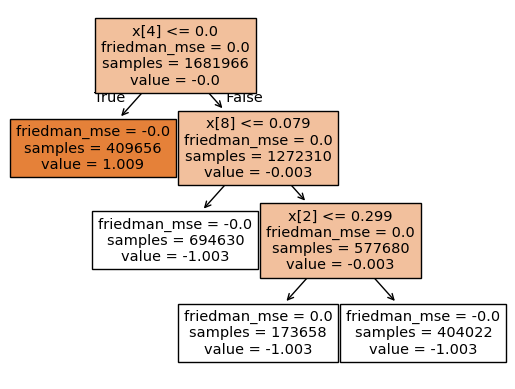

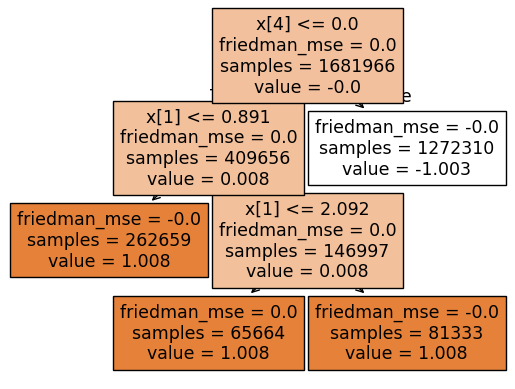

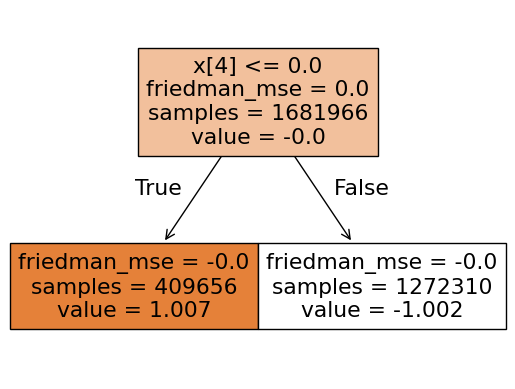

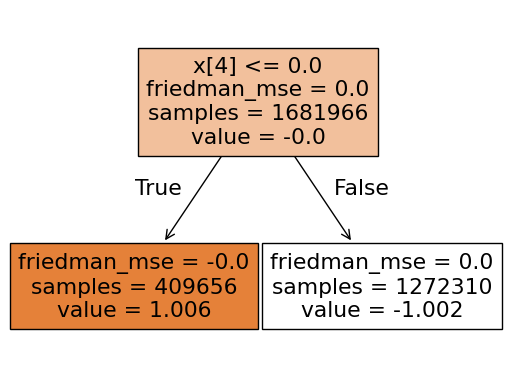

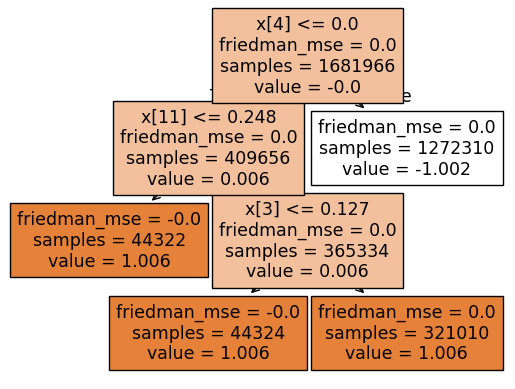

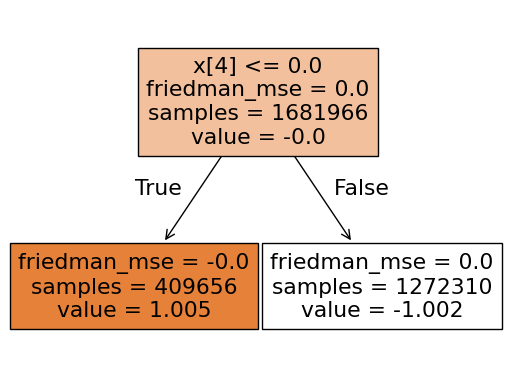

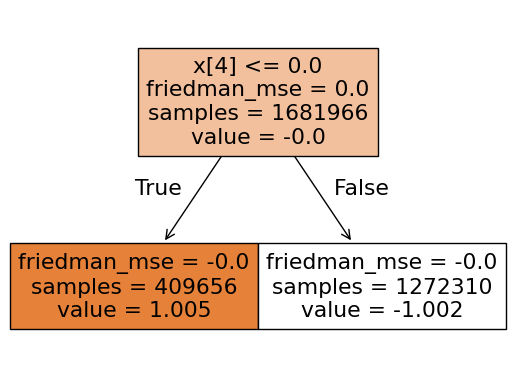

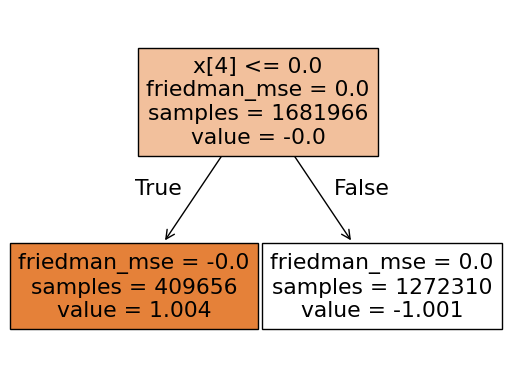

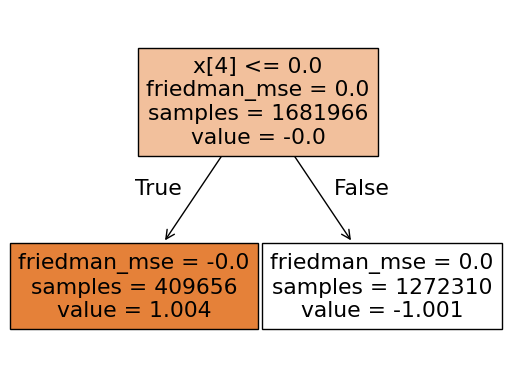

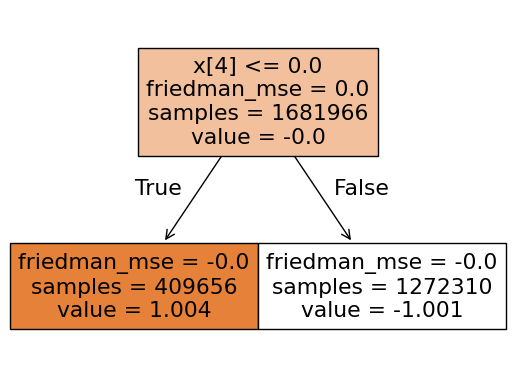

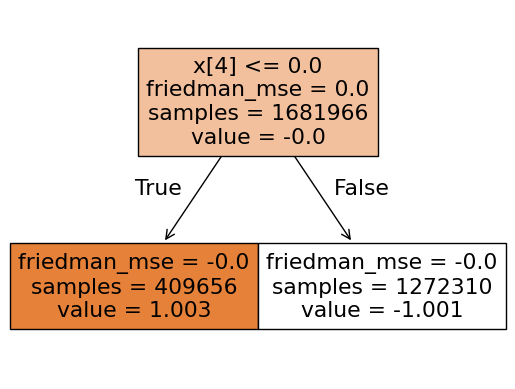

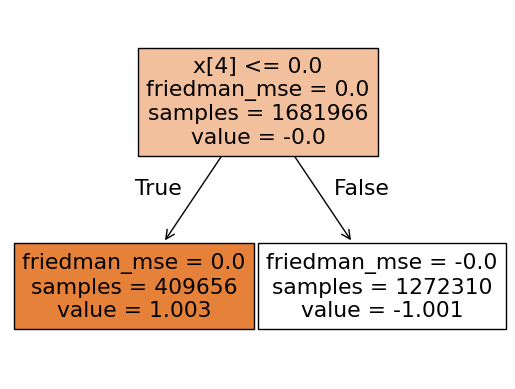

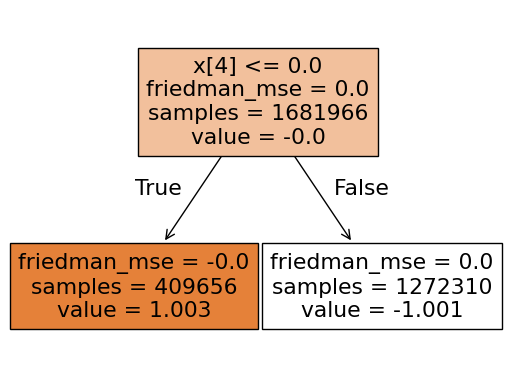

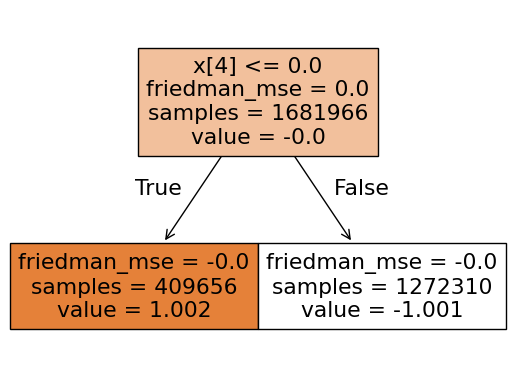

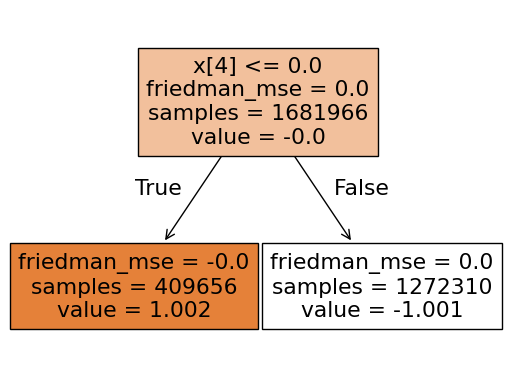

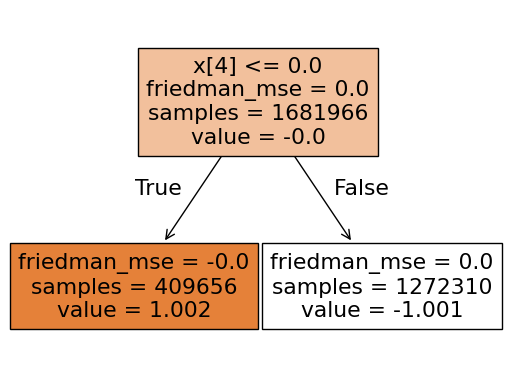

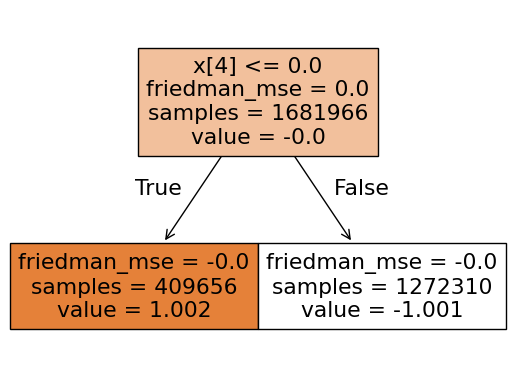

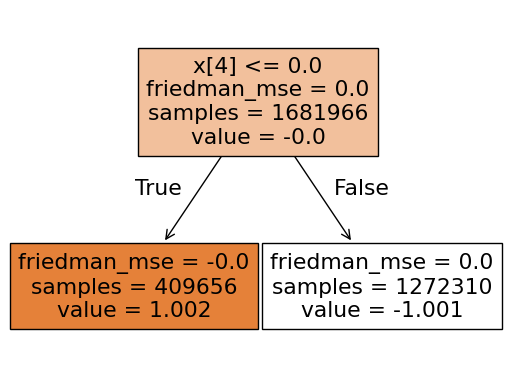

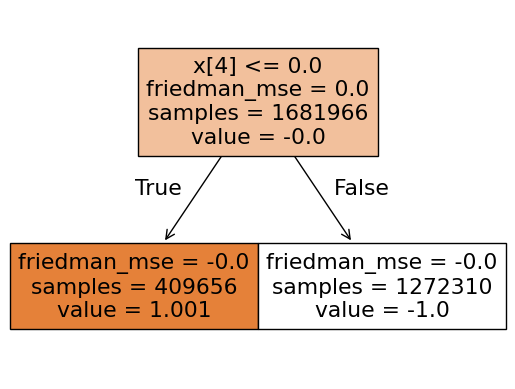

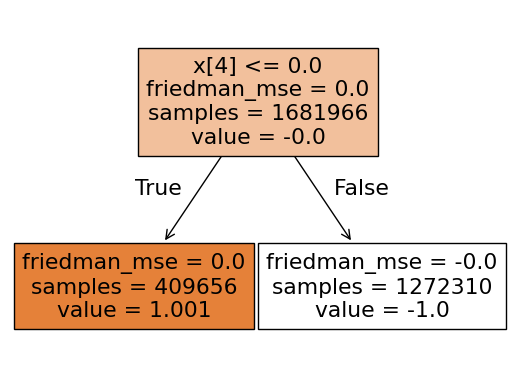

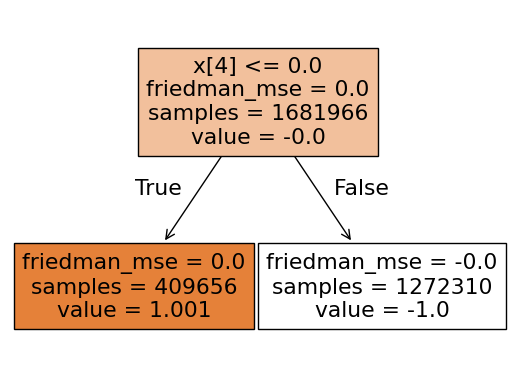

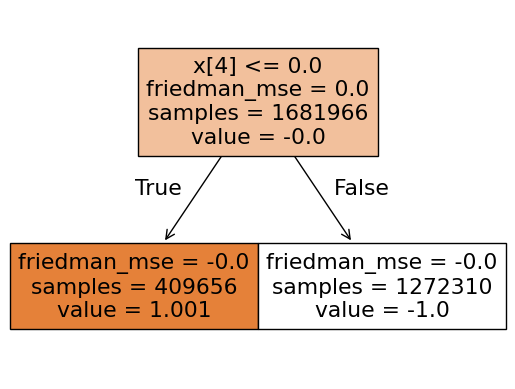

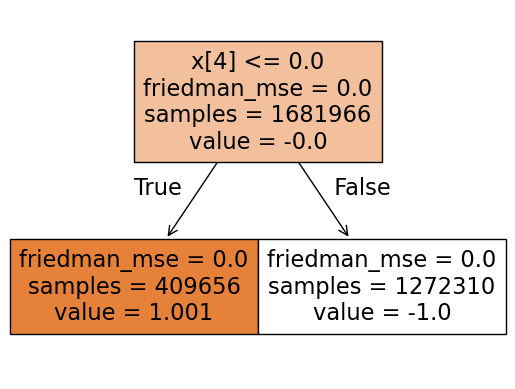

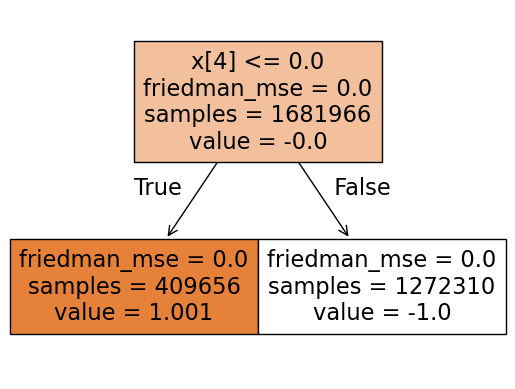

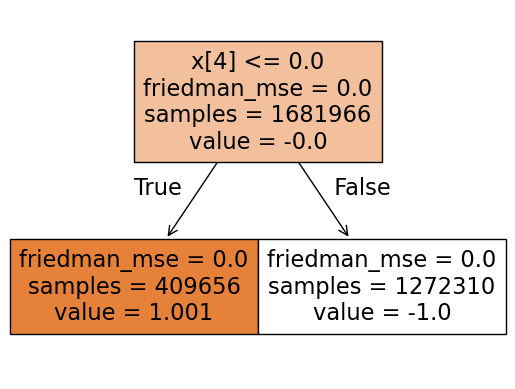

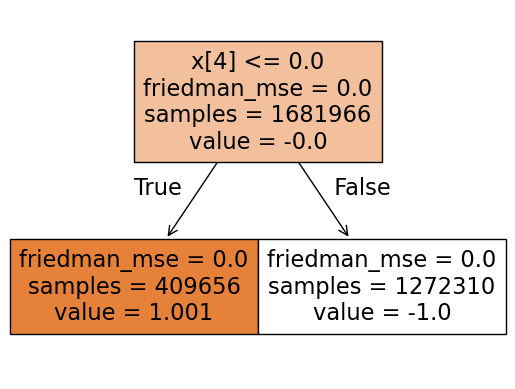

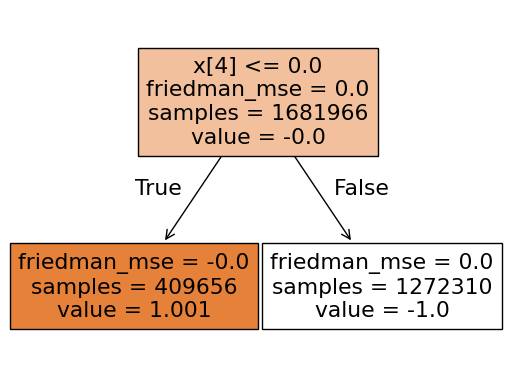

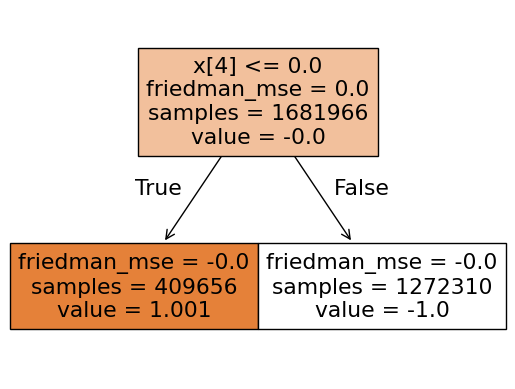

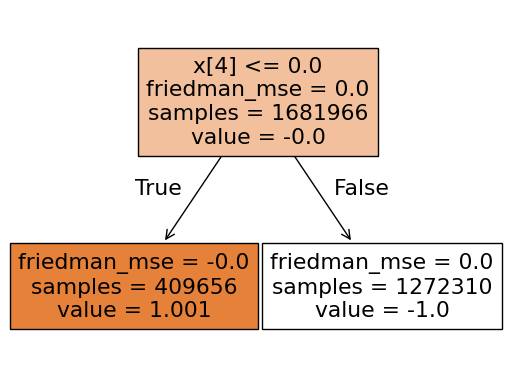

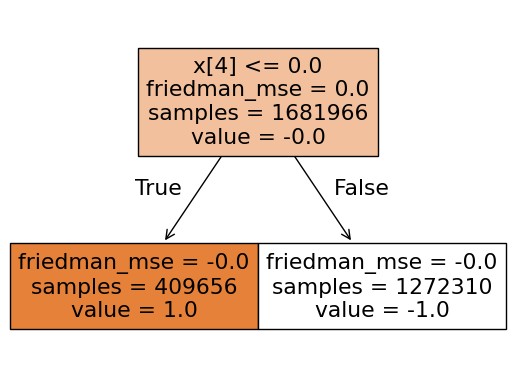

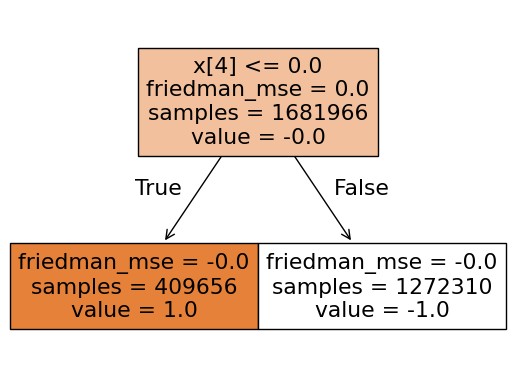

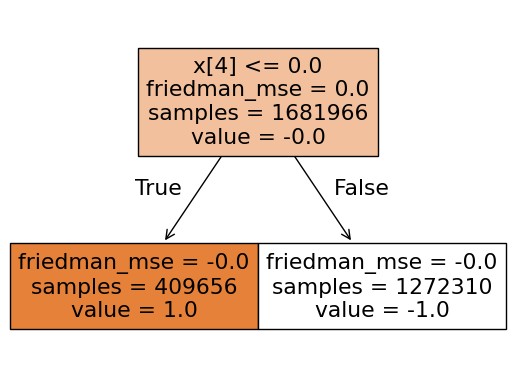

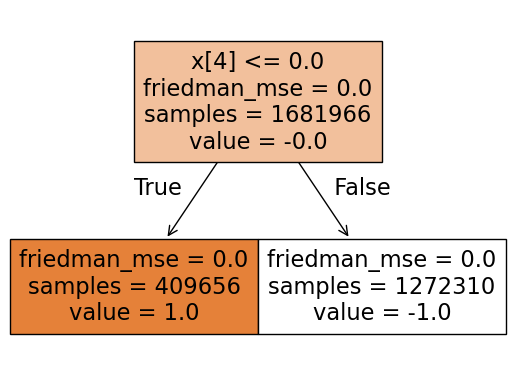

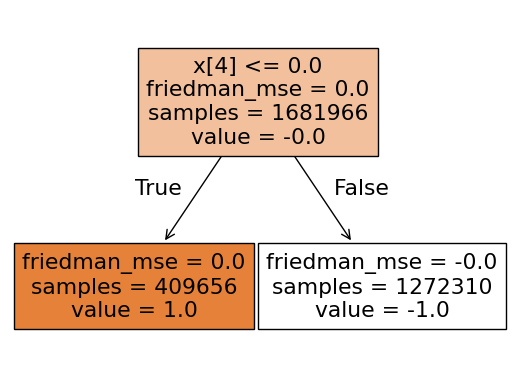

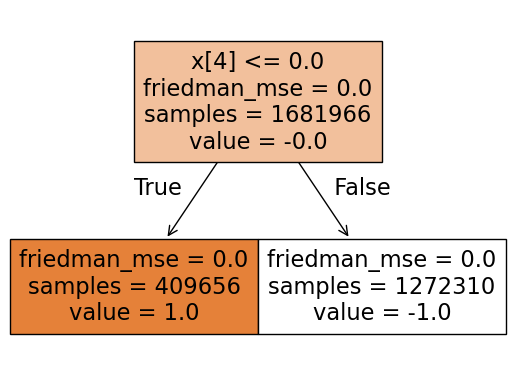

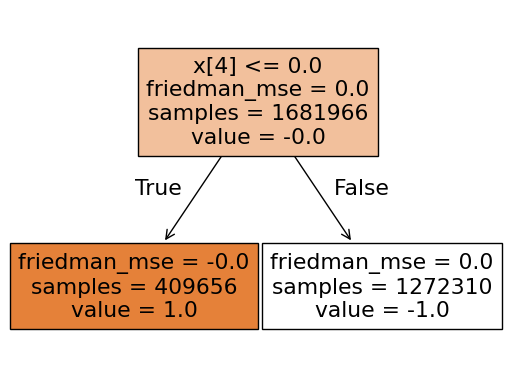

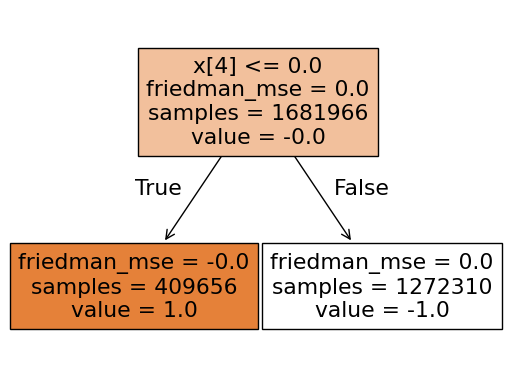

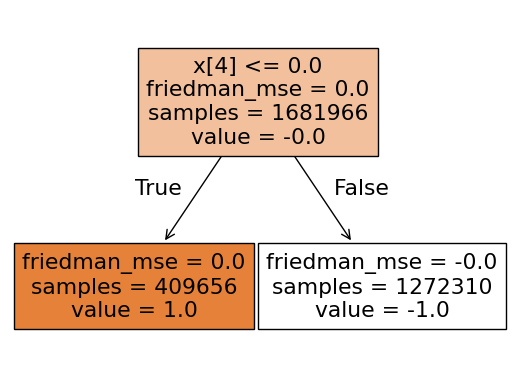

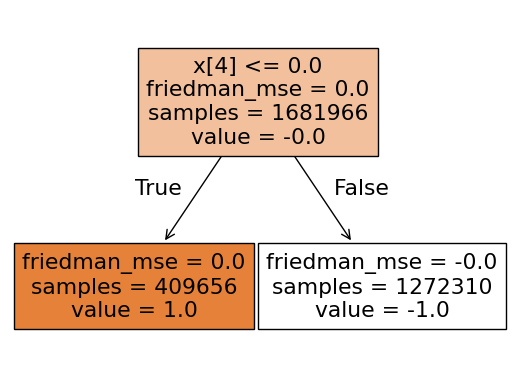

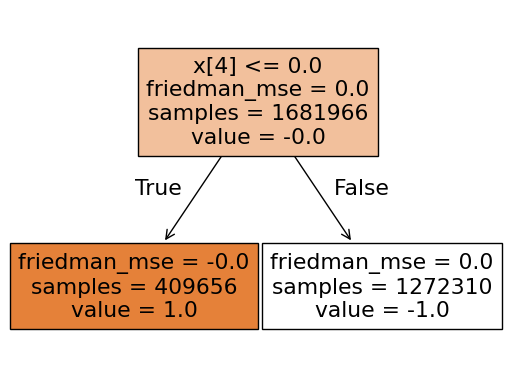

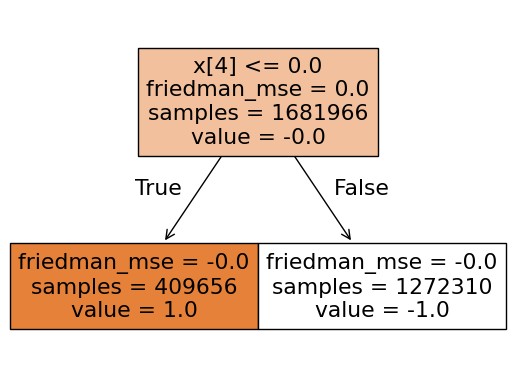

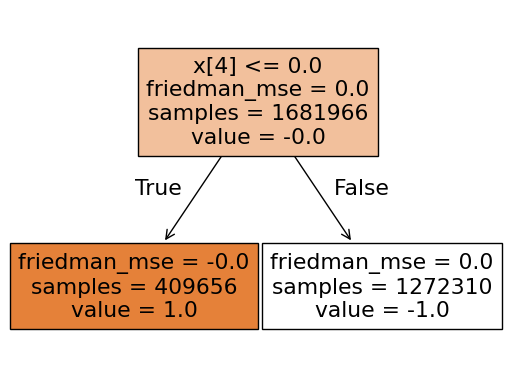

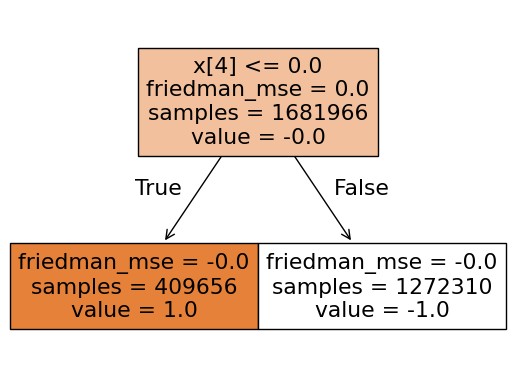

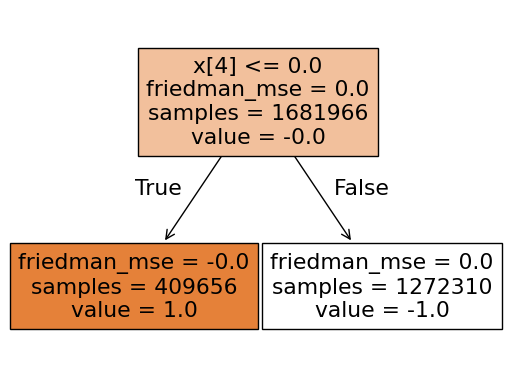

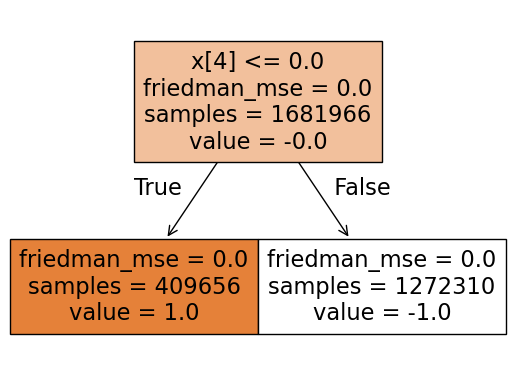

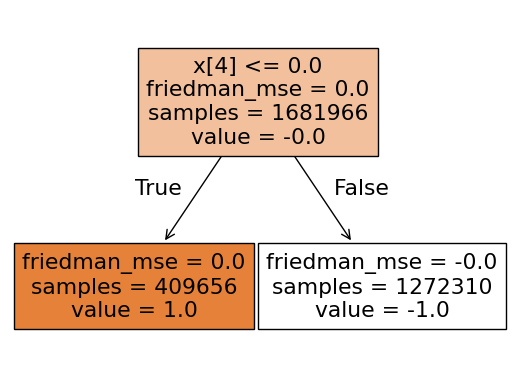

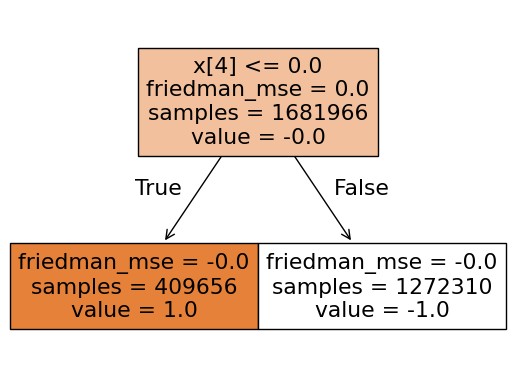

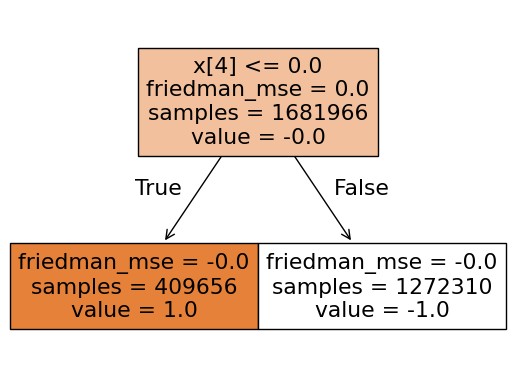

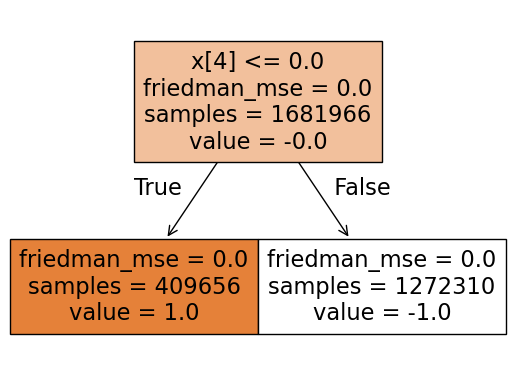

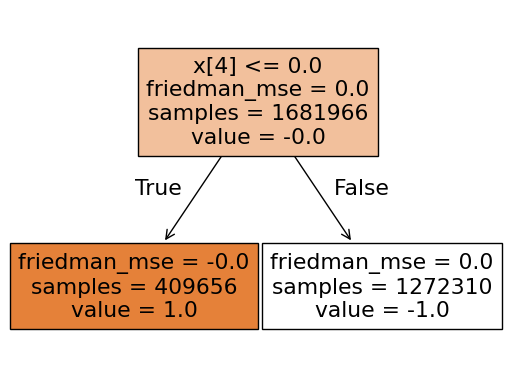

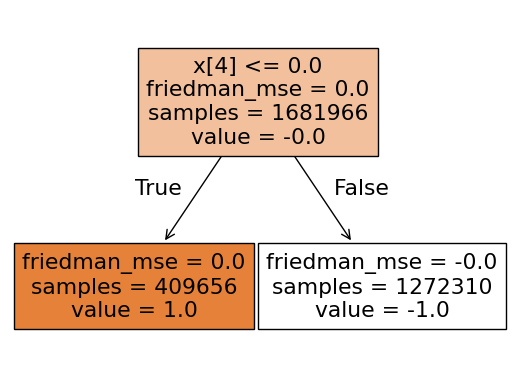

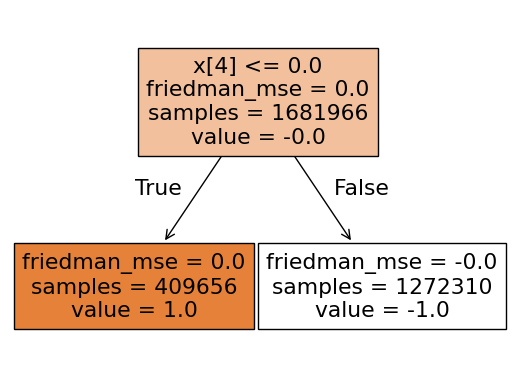

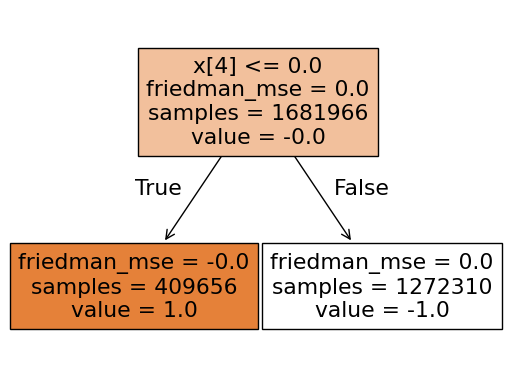

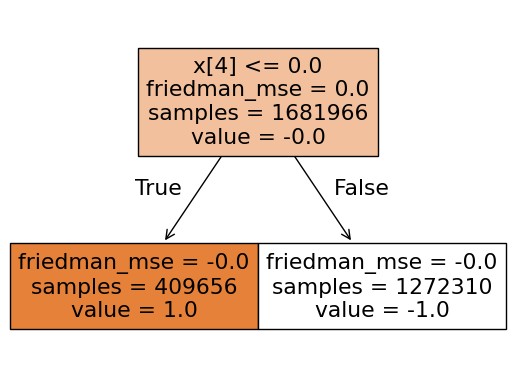

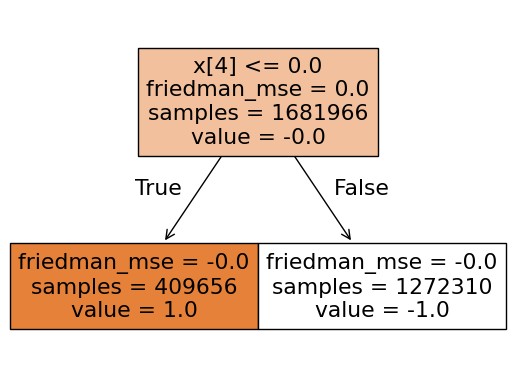

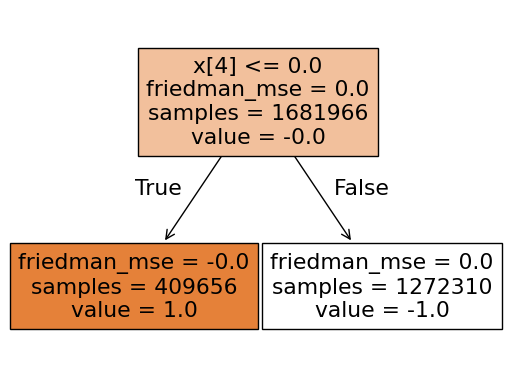

In [11]:
from sklearn.tree import plot_tree

for est in clf.estimators_.flatten():
    gbc_sub_tree = est
    plot_tree(gbc_sub_tree, filled=True)
    plt.show()